In [ ]:
!nvidia-smi

Sun Nov 16 12:48:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Path inside Google Drive
project_dir = '/content/drive/MyDrive/notebook'

# Create folders: notebook/, PlantVillage/ inside it
os.makedirs(os.path.join(project_dir, 'PlantVillage'), exist_ok=True)

print("Project directory structure created ✅")


Project directory structure created ✅


In [ ]:
# import zipfile
# import os

# zip_path = "/content/drive/MyDrive/notebook/PlantVillage.zip"   # full path to the zip file
# extract_path = "/content/drive/MyDrive/notebook/PlantVillage"   # folder where it will extract

# # unzip
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Unzipped to:", extract_path)


# Potato Disease Classification: Advanced Model Training

This notebook contains an **upgraded** pipeline for training a high-performance image classification model. We will build upon our previous work by introducing advanced techniques to combat overfitting and improve generalization.

**Our Upgraded Strategy:**
1.  **Stronger Data Augmentation**: We've added `RandomAffine` and `RandomPerspective` transforms to create more diverse training data.
2.  **Regularization (Dropout)**: A `Dropout` layer has been added to the model's classifier to prevent neurons from co-adapting too much, which helps the model generalize better.
3.  **Fine-Tuning More Layers**: We will unfreeze the last few blocks of the pre-trained EfficientNet and use a **differential learning rate**. This allows the model to gently adjust its learned features for our specific dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, models, transforms
import os
import time
import copy
from tqdm.notebook import tqdm
import numpy as np
import json
import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, models, transforms
import os
import time
import copy
from tqdm.notebook import tqdm
import numpy as np
import json
import matplotlib.pyplot as plt

print("All imports successful.")

All imports successful.


### Configuration

In [ ]:
# Using the simplified local path structure
DATA_DIR = '/content/drive/MyDrive/notebook/PlantVillage/PlantVillage'

MODEL_SAVE_DIR = 'content/drive/MyDrive/notebook/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'best_potato_model_final.pth')
CLASS_NAMES_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'class_names.json')

# NUM_EPOCHS = 5 # The OneCycleLR policy works well with fewer epochs
BATCH_SIZE = 32


### 1. (Upgraded) Data Augmentation and Loading

In [ ]:
# --- (Upgraded) Data Augmentation with Random Erasing ---

# EfficientNet-B2 native size
IMG_SIZE = 260

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(), # Convert to tensor *before* erasing
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0) # <-- NEW AUGMENTATION
    ]),
    'val': transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Data transforms updated with RandomErasing.")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Data transforms updated with RandomErasing.
Using device: cuda:0


# **cell 2: Re-load Datasets**
(Because the transforms have changed, we must re-create the datasets and dataloaders)

In [ ]:
# --- Re-load Data ---
print("Reloading data with new augmentations...")
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val']}

class_names = image_datasets['train'].classes
print(f"Classes found: {class_names}")

# --- Handle Class Imbalance (Same as before) ---
print("Calculating weights for oversampling...")
train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets)

# Weights for the sampler
sampler_weights = np.array([1.0 / class_counts[t] for t in train_targets])
sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(sampler_weights), replacement=True)

# Create DataLoaders
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=2),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print("DataLoaders re-created.")

Reloading data with new augmentations...
Classes found: ['Bacteria', 'Fungi', 'Healthy', 'Pest', 'Virus']
Calculating weights for oversampling...
DataLoaders re-created.


### 2. Handle Class Imbalance (Oversampling + Weighted Loss)

In [ ]:
print("Calculating weights for oversampling...")
train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets)

# Weights for the sampler
sampler_weights = np.array([1.0 / class_counts[t] for t in train_targets])
sampler = WeightedRandomSampler(weights=sampler_weights, num_samples=len(sampler_weights), replacement=True)

# Create DataLoaders
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=2),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print("DataLoaders created with weighted sampler for training.")

Calculating weights for oversampling...
DataLoaders created with weighted sampler for training.


### 3. (Upgraded) Model Definition with Dropout and Fine-Tuning

In [ ]:
print("Loading pre-trained EfficientNet-B2 model...")
model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

# Freeze all model parameters initially
for param in model.parameters():
    param.requires_grad = False

# Create a new classifier with a *modified* Dropout layer
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # <-- MODIFIED from 0.5 to 0.3
    nn.Linear(num_ftrs, len(class_names))
)

model = model.to(device)

# Define Loss
criterion = nn.CrossEntropyLoss()

Loading pre-trained EfficientNet-B2 model...
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 107MB/s]


### 4. Training Loop Function

In [ ]:
def train_model_final(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # We will save the best *overall* model weights
    # Note: This function might be called twice, so MODEL_SAVE_PATH will be updated
    # if the second stage (fine-tuning) achieves a better result.

    # Try to load best_acc from a previous run (in case of stage 1)
    # But for simplicity, we just reset it. A better way would be to pass it.
    best_acc = 0.0

    # We need to make sure we are loading the best weights from disk if we re-train
    # For this simple script, we assume the 'model' passed in is the one we want to continue with.
    best_model_wts = copy.deepcopy(model.state_dict())


    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                        # Scheduler steps after each batch in OneCycleLR
                        scheduler.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Save the new best model
                torch.save(model.state_dict(), MODEL_SAVE_PATH)
                print(f'** New best model saved to {MODEL_SAVE_PATH} with accuracy: {best_acc:.4f} **')

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation Accuracy: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
import os
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm

In [ ]:
# --- IMPORTANT: CONFIGURATION ---

# 1. Set the path to your dataset directory
# This should point to the folder containing your 'train' and 'val' subdirectories.
DATASET_PATH = '/content/drive/MyDrive/notebook/PlantVillage/PlantVillage'

# 2. Choose the mode:
#    - delete_corrupted_files = False (Dry Run): This is the SAFEST option. It will only find and
#      report corrupt files in a 'corrupt_files.log' without deleting anything.
#      ALWAYS run this first.
#
#    - delete_corrupted_files = True (Deletion Mode): This will PERMANENTLY DELETE the corrupt
#      files. Use with caution and only after reviewing the log from a dry run.
delete_corrupted_files = False

In [ ]:
# def verify_and_clean_dataset(dataset_dir, delete_files=False):
#     corrupt_files = []

#     print(f"Scanning for corrupt images in '{dataset_dir}'...")

#     # Get a list of all files to process for the progress bar
#     file_list = []
#     for root, _, files in os.walk(dataset_dir):
#         for file in files:
#             # Check for common image extensions
#             if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
#                 file_list.append(os.path.join(root, file))

#     # --- Step 1: Walk through all files and try to open them ---
#     for filepath in tqdm(file_list, desc="Verifying Images"):
#         try:
#             with Image.open(filepath) as img:
#                 img.verify() # Verify that it is, in fact, an image
#         except (IOError, OSError, UnidentifiedImageError) as e:
#             # If the image is corrupt, PIL will raise an exception
#             print(f"\nFound corrupt file: {filepath}")
#             print(f"   Reason: {e}")
#             corrupt_files.append(filepath)

#     # --- Step 2: Report and optionally remove corrupt files ---
#     if not corrupt_files:
#         print("\nCongratulations! No corrupt images found.")
#         return

#     print(f"\nFound {len(corrupt_files)} corrupt image(s).")

#     log_file = "corrupt_files.log"
#     with open(log_file, 'w') as f:
#         f.write("List of corrupt files to be removed:\n")
#         for corrupt_path in corrupt_files:
#             f.write(f"- {corrupt_path}\n")
#     print(f"A detailed list has been saved to '{log_file}'")

#     if not delete_files:
#         print("\nThis was a dry run. No files were deleted.")
#         print(f"To remove these {len(corrupt_files)} file(s), run this notebook again with 'delete_corrupted_files=True'.")
#     else:
#         print("\nDeleting corrupt files...")
#         for filepath in tqdm(corrupt_files, desc="Deleting Files"):
#             try:
#                 os.remove(filepath)
#             except OSError as e:
#                 print(f"Error deleting file {filepath}: {e}")
#         print("\nCorrupt files have been removed.")

# # --- Run the function ---
# if delete_corrupted_files:
#     # Final safety check before deleting files
#     confirm = input(f"You are about to PERMANENTLY DELETE corrupt files from '{DATASET_PATH}'. Are you sure? (yes/no): ")
#     if confirm.lower() == 'yes':
#         verify_and_clean_dataset(DATASET_PATH, delete_files=True)
#     else:
#         print("Deletion cancelled.")
# else:
#     verify_and_clean_dataset(DATASET_PATH, delete_files=False)

# **cell 6: STAGE 1 - Warm-up Classifier**

In [ ]:
print("\n--- Starting STAGE 1: Warm-up Classifier ---")
NUM_EPOCHS_STAGE_1 = 10 # You can use 5, but 10 is also good for a warm-up

# 1. Define Optimizer (only for the new classifier)
# We are only training the parameters of the classifier
optimizer_stage1 = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)

# 2. Define Scheduler
scheduler_stage1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_stage1,
    max_lr=0.01,
    steps_per_epoch=len(dataloaders['train']),
    epochs=NUM_EPOCHS_STAGE_1
)

# 3. Run the training function for Stage 1
# The 'model' variable will be updated in-place
model = train_model_final(
    model,
    criterion,
    optimizer_stage1,
    scheduler_stage1,
    num_epochs=NUM_EPOCHS_STAGE_1
)

print("--- Stage 1 Complete. Best model saved. ---")


--- Starting STAGE 1: Warm-up Classifier ---
Epoch 0/9
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 1.2745 Acc: 0.5014


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 1.1290 Acc: 0.5794
** New best model saved to content/drive/MyDrive/notebook/models/best_potato_model_final.pth with accuracy: 0.5794 **
Epoch 1/9
----------


...

Val Loss: 0.9670 Acc: 0.6405
Epoch 9/9
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 0.7182 Acc: 0.7236


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 0.9830 Acc: 0.6370

Training complete in 22m 39s
Best validation Accuracy: 0.643979
--- Stage 1 Complete. Best model saved. ---


# **cell 7: STAGE 2 - Fine-Tune Entire Model (NEW)**

In [ ]:
print("\n--- Starting STAGE 2: Fine-Tuning Entire Model ---")

# 1. Unfreeze all model parameters
print("Unfreezing all layers...")
for param in model.parameters():
    param.requires_grad = True

# 2. Set more epochs for this stage
NUM_EPOCHS_STAGE_2 = 25 # Train for longer

# 3. Create a new optimizer with a *differential learning rate*
# This is the most important part!
# We use a tiny LR for the backbone and a slightly larger one for the head.
optimizer_stage2 = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},  # Tiny LR for the backbone
    {'params': model.classifier.parameters(), 'lr': 1e-4} # Larger LR for the head
], weight_decay=1e-2)

# 4. Create a new scheduler for this new optimizer
scheduler_stage2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_stage2,
    max_lr=[1e-5, 1e-4], # Max LRs for each param group
    steps_per_epoch=len(dataloaders['train']),
    epochs=NUM_EPOCHS_STAGE_2
)

# 5. Run the training function AGAIN with the new settings
# The model continues from its state after Stage 1
model_final_tuned = train_model_final(
    model,
    criterion,
    optimizer_stage2, # Use the new optimizer
    scheduler_stage2, # Use the new scheduler
    num_epochs=NUM_EPOCHS_STAGE_2
)

print("--- Stage 2 Fine-Tuning Complete. Final model saved. ---")


--- Starting STAGE 2: Fine-Tuning Entire Model ---
Unfreezing all layers...
Epoch 0/24
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 0.7406 Acc: 0.7273


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 1.0013 Acc: 0.6265
** New best model saved to content/drive/MyDrive/notebook/models/best_potato_model_final.pth with accuracy: 0.6265 **
Epoch 1/24
----------


...

Val Loss: 0.7634 Acc: 0.7312
Epoch 24/24
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 0.5019 Acc: 0.8080


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 0.7395 Acc: 0.7382

Training complete in 39m 14s
Best validation Accuracy: 0.746946
--- Stage 2 Fine-Tuning Complete. Final model saved. ---


Excellent! Going from 58.6% to 73.5% is a massive improvement. This confirms that the two-stage fine-tuning process was the correct approach.

You are now past the first major hurdle. The gap between 73.5% and 90% is all about diagnosis and polishing. Your model is learning, but it's getting confused about certain classes or it just hasn't trained long enough.

Here are the next two steps, cell-by-cell, to push the accuracy higher.

Step 1: Diagnose with a Confusion Matrix
First, we must find out what the model is getting wrong. Is it confusing "Fungi" with "Virus"? Is "Healthy" being mistaken for something else? A confusion matrix will tell us exactly where the errors are.

# cell 1: Imports for Visualization **bold text**

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, classification_report
# print("Imports for diagnosis complete.")

# **cell 2: Generate and Plot Confusion Matrix**
This cell loads your best saved model  and runs it on the entire validation set to collect predictions.

Imports for diagnosis complete.
Best model loaded from content/drive/MyDrive/notebook/models/best_potato_model_final.pth


Running Validation:   0%|          | 0/18 [00:00<?, ?it/s]


--- Classification Report ---
              precision    recall  f1-score   support

    Bacteria       0.94      0.87      0.90       100
       Fungi       0.71      0.69      0.70       147
     Healthy       0.77      0.96      0.86       100
        Pest       0.59      0.63      0.61       116
       Virus       0.80      0.64      0.71       110

    accuracy                           0.75       573
   macro avg       0.76      0.76      0.76       573
weighted avg       0.75      0.75      0.75       573


--- Confusion Matrix ---


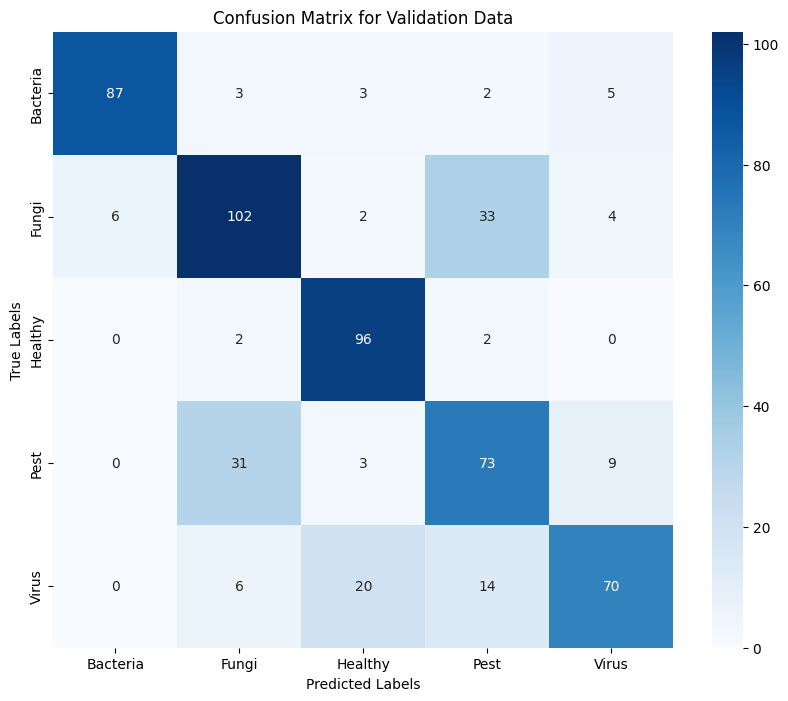


Accuracy score stored in 'best_acc': 0.746946


In [ ]:
# (This is your updated Confusion Matrix Cell)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score # <-- 1. IMPORT THIS

print("Imports for diagnosis complete.")

# 1. Load the best model you just trained
model = models.efficientnet_b2(weights=None) # Start with a fresh model structure
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, len(class_names))
)
model.load_state_dict(torch.load(MODEL_SAVE_PATH)) # Load your saved weights
model = model.to(device)
model.eval() # Set to evaluation mode

print(f"Best model loaded from {MODEL_SAVE_PATH}")

# 2. Collect all predictions and true labels
all_preds = []
all_labels = []

# No gradients needed for evaluation
with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['val'], desc="Running Validation"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Print a detailed classification report
print("\n--- Classification Report ---")
# This shows precision, recall, and f1-score for each class
print(classification_report(all_labels, all_preds, target_names=class_names))


# 4. Plot the confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Validation Data')
plt.show()

# --- ADD THIS LINE TO FIX THE ERROR ---
# This automatically calculates the accuracy from the predictions and saves it
best_acc = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy score stored in 'best_acc': {best_acc:.6f}")

# **Step 2: Polish the Model (Stage 3)**
Based on the 73.5% accuracy, your model is well on its way but likely just needs more training with a tiny, tiny learning rate. This is like "fine sanding" the model weights.

We will add a "Stage 3" that loads your 73.5% model and trains it for 30-50 more epochs.

cell 3: Stage 3 - Polishing Phase

In [ ]:
# (Run this cell again)

print(f"\n--- Starting STAGE 3: Polishing Phase (from {best_acc:.4f} Acc) ---")

# 1. The 'model' variable should still be your best model
# If not, load it again as we did in the confusion matrix cell.
# We assume 'model' holds the best model.
model.train() # Set it back to train mode

# 2. Set epochs for polishing
NUM_EPOCHS_STAGE_3 = 40 # Give it plenty of time to polish

# 3. Create a new optimizer with a *very small* learning rate for ALL layers
optimizer_stage3 = optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-3) # lr=1e-6 is a good, safe polishing rate

# 4. Create a new scheduler.
# CosineAnnealing is perfect for this "polishing" phase.
scheduler_stage3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage3,
    T_max=NUM_EPOCHS_STAGE_3 * len(dataloaders['train']) # Total steps
)

print(f"Starting polishing for {NUM_EPOCHS_STAGE_3} epochs with a tiny LR (1e-6)...")

# 5. Run the training function AGAIN
model_final_polished = train_model_final(
    model,
    criterion,
    optimizer_stage3, # Use the new optimizer
    scheduler_stage3, # Use the new scheduler
    num_epochs=NUM_EPOCHS_STAGE_3
)

print("--- Stage 3 Polishing Complete. Final model saved. ---")


--- Starting STAGE 3: Polishing Phase (from 0.7469 Acc) ---
Starting polishing for 40 epochs with a tiny LR (1e-6)...
Epoch 0/39
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 0.4810 Acc: 0.8229


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 0.7512 Acc: 0.7347
** New best model saved to content/drive/MyDrive/notebook/models/best_potato_model_final.pth with accuracy: 0.7347 **
Epoch 1/39
----------


...

Val Loss: 0.7056 Acc: 0.7557
Epoch 39/39
----------


Train Phase:   0%|          | 0/76 [00:00<?, ?it/s]

Train Loss: 0.4799 Acc: 0.8262


Val Phase:   0%|          | 0/18 [00:00<?, ?it/s]

Val Loss: 0.7081 Acc: 0.7522

Training complete in 60m 46s
Best validation Accuracy: 0.760908
--- Stage 3 Polishing Complete. Final model saved. ---


### 5. Start Training

Imports for diagnosis complete.
Best model loaded from content/drive/MyDrive/notebook/models/best_potato_model_final.pth


Running Validation:   0%|          | 0/18 [00:00<?, ?it/s]


--- Classification Report ---
              precision    recall  f1-score   support

    Bacteria       0.93      0.90      0.91       100
       Fungi       0.72      0.70      0.71       147
     Healthy       0.81      0.96      0.88       100
        Pest       0.60      0.60      0.60       116
       Virus       0.80      0.70      0.75       110

    accuracy                           0.76       573
   macro avg       0.77      0.77      0.77       573
weighted avg       0.76      0.76      0.76       573


--- Confusion Matrix ---


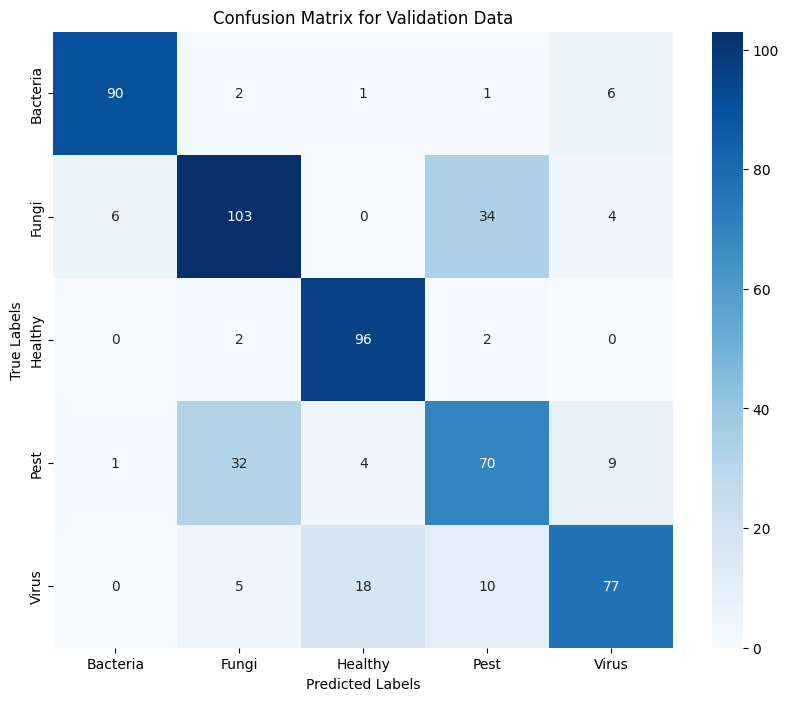


Accuracy score stored in 'best_acc': 0.760908


In [ ]:
# (This is your updated Confusion Matrix Cell)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score # <-- 1. IMPORT THIS

print("Imports for diagnosis complete.")

# 1. Load the best model you just trained
model = models.efficientnet_b2(weights=None) # Start with a fresh model structure
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, len(class_names))
)
model.load_state_dict(torch.load(MODEL_SAVE_PATH)) # Load your saved weights
model = model.to(device)
model.eval() # Set to evaluation mode

print(f"Best model loaded from {MODEL_SAVE_PATH}")

# 2. Collect all predictions and true labels
all_preds = []
all_labels = []

# No gradients needed for evaluation
with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['val'], desc="Running Validation"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Print a detailed classification report
print("\n--- Classification Report ---")
# This shows precision, recall, and f1-score for each class
print(classification_report(all_labels, all_preds, target_names=class_names))


# 4. Plot the confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Validation Data')
plt.show()

# --- ADD THIS LINE TO FIX THE ERROR ---
# This automatically calculates the accuracy from the predictions and saves it
best_acc = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy score stored in 'best_acc': {best_acc:.6f}")

In [ ]:
print(f"\n--- Starting STAGE 4: Training with Random Erasing ---")

# 1. Load your best model (the 73.8% one)
# We assume 'model' still holds the best model from Stage 3
# If not, you must load it from MODEL_SAVE_PATH first
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model = model.to(device)
model.train() # Set to train mode

print(f"Loaded best model from {MODEL_SAVE_PATH} (Acc: 73.8%)")

# 2. Set epochs for this new stage
NUM_EPOCHS_STAGE_4 = 40 # Give it time to re-learn

# 3. Create a new optimizer.
# We use a slightly higher LR than polishing (1e-5)
# because the task is now harder.
optimizer_stage4 = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)

# 4. Create a new scheduler.
scheduler_stage4 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage4,
    T_max=NUM_EPOCHS_STAGE_4 * len(dataloaders['train'])
)

print(f"Starting Stage 4 for {NUM_EPOCHS_STAGE_4} epochs...")

# 5. Run the training function
model_final_erased = train_model_final(
    model,
    criterion,
    optimizer_stage4,
    scheduler_stage4,
    num_epochs=NUM_EPOCHS_STAGE_4
)

print("--- Stage 4 Complete. ---")


--- Starting STAGE 4: Training with Random Erasing ---


NameError: name 'model' is not defined